In [1]:
import sys, platform, pathlib
sys.path.insert(0, str(pathlib.Path().resolve().parent.parent / "src"))
import geopops
import sciris as sc
import starsim as ss
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from enum import IntEnum
import itertools
from collections import defaultdict
from scipy.special import logsumexp
np.random.seed(123)

# GeoPops Config

In [2]:
pars_geopops = {"path": "/Users/Alisa/Library/CloudStorage/OneDrive-JohnsHopkins/Research/GeoPops_all/geopops/tutorials/Epidemics",
                "census_api_key": "4ab35c539d0d99127684ce3a387231ee78612a46",
                "julia_env_path": "/Users/Alisa/.julia/environments/v1.9",# Path to your Julia environment, "/Users/Name/.julia/environments/v1.9" or “C:/YOUR PATH TO JULIA/.julia/environments/v1.9/Project.toml” 
                'main_year': 2019, # Year of data
                'geos': ["24027"], # Example of Howard County, MD
                'commute_states': ["24"], # State fips of commute data to download
                'use_pums': ["24"]} # State fips of PUMS data to download

c = geopops.WriteConfig(**pars_geopops)

Updated config.json with new parameters


# SIRS model

In [3]:
# Define parameters
dis_beta = 0.6 # beta passed into disease class and transmission matrix function. MixingPools beta is a completely different thing
gamma = 1/7 # recovery rate # define outside because passed in disease and transition matrix
alpha = 0.008 # waning rate # define outside because passed in disease and transition matrix
init_prev = 0.001

class SIRS(ss.Infection):
    """
    Example SIRS model
    """
    def __init__(self, pars=None, **kwargs):
        super().__init__()
        self.define_pars(
            init_prev = ss.bernoulli(p=init_prev),
            beta = ss.per(dis_beta, unit='day'), 
            recover = ss.bernoulli(gamma),
            wane = ss.bernoulli(p=alpha),
        )
        self.update_pars(pars, **kwargs)

        self.define_states(
            ss.BoolState('susceptible', default=True, label='Susceptible'),
            ss.BoolState('infected', label='Infectious'),
            ss.BoolState('recovered', label='Recovered'),
            ss.FloatArr('rel_sus', default=1.0, label='Relative susceptibility'),
            ss.FloatArr('rel_trans', default=1.0, label='Relative transmission'),
            ss.FloatArr('ti_infected', label='Time of infection'),
            reset = True
        )
        return

    def step_state(self):
        p = self.pars
        recovered = p.recover.filter(self.infected)
        waned = p.wane.filter(self.recovered)
        self.infected[recovered] = False
        self.recovered[recovered] = True
        self.recovered[waned] = False
        self.susceptible[waned] = True
        return

    def set_prognoses(self, uids, sources=None):
        super().set_prognoses(uids, sources)
        ti = self.ti
        self.susceptible[uids] = False
        self.infected[uids] = True
        self.recovered[uids] = False
        self.ti_infected[uids] = ti
        return

    def plot(self):
        fig = plt.figure()
        mapping = dict(n_susceptible='Susceptible', n_infected='Infectious', n_recovered='Recovered')
        for key,label in mapping.items():
            plt.plot(self.results[key], label=label)
        plt.legend()
        plt.show()
        print('beta=', self.pars.beta[0])
        return fig

# People

In [4]:
ppl = geopops.ForStarsim.People()
sim = ss.Sim(people=ppl).init()
# len(sim.people.to_df()['cbg_id'].unique())


Creating Starsim People object from GeoPops data


/Users/Alisa/Library/CloudStorage/OneDrive-JohnsHopkins/Research/GeoPops_all/geopops/.venv/lib/python3.12/site-packages/starsim/utils.py:89: RuntimeWarning: 
Overwriting existing ndict entry "age"
  ss.warn(f'Overwriting existing ndict entry "{key}"')
/Users/Alisa/Library/CloudStorage/OneDrive-JohnsHopkins/Research/GeoPops_all/geopops/.venv/lib/python3.12/site-packages/starsim/utils.py:89: RuntimeWarning: 
Overwriting existing ndict entry "female"
  ss.warn(f'Overwriting existing ndict entry "{key}"')


Initializing sim with 426595 agents
Starsim People object created and saved successfully
Initializing sim with 426595 agents


In [5]:
# Create attribute for hassle cost. Assign 1/3 of pop to each level (low, medium, high)
class HSL(IntEnum):
    LOW = 0
    MEDIUM = 1
    HIGH = 2
    
class WRK(IntEnum): # this is working not worker!!
    NO = 0
    YES = 1

class WORKER(IntEnum): # this is worker!!
    NO = 0
    YES = 1
    
class VUL(IntEnum):
    LOW = 1
    HIGH = 2
    
class SES(IntEnum):
    LOW = 1
    HIGH = 2

# Networks

In [6]:
work_beta = 4.0

h = geopops.ForStarsim.GPNetwork(name='homenet', beta_value=1.0)
s = geopops.ForStarsim.GPNetwork(name='schoolnet', beta_value=1.0)
w = geopops.ForStarsim.GPNetwork(name='worknet', beta_value=work_beta)
g = geopops.ForStarsim.GPNetwork(name='gqnet', beta_value=1.0)

sim = ss.Sim(diseases=SIRS(), people=ppl, networks=[h,s,w,g]).init()
# np.sum(sim.networks.schoolnet.edges.beta > 0.0)

Network csv files created and saved successfully
Initializing sim with 426595 agents


/Users/Alisa/Library/CloudStorage/OneDrive-JohnsHopkins/Research/GeoPops_all/geopops/.venv/lib/python3.12/site-packages/numba/cpython/hashing.py:477: UserWarning: FNV hashing is not implemented in Numba. See PEP 456 https://www.python.org/dev/peps/pep-0456/ for rationale over not using FNV. Numba will continue to work, but hashes for built in types will be computed using siphash24. This will permit e.g. dictionaries to continue to behave as expected, however anything relying on the value of the hash opposed to hash as a derived property is likely to not work as expected.
  warnings.warn(msg)


# Transition matrices

In [7]:
def single_matrix(risk_group, network_names):
    # Initialize dictionary - will store: {uid: [list of all contact UIDs from all networks]}
    contacts_dict = defaultdict(list)
    
    # Convert s_workers to a set for fast lookup
    # s_workers contains UIDs of people who are: working (wrk == WRK.YES) AND susceptible
    risk_group_set = set(risk_group)
    
    # Get infected UIDs as a set for fast lookup
    infected_uids = set(ss.uids(sim.people.sirs.infected == 1.0))
    
    # Process each network and accumulate contacts
    # This loop processes all networks, so contacts from all specified networks
    # are all added to the same contacts_dict dictionary
    for network_name in network_names:
        network = getattr(sim.networks, network_name)
        p1_uids = network.edges.p1
        p2_uids = network.edges.p2
        
        # Check if beta values exist and filter active edges
        if hasattr(network.edges, 'beta') and network.edges.beta is not None:
            beta_values = network.edges.beta
            active_mask = beta_values > 0
            p1_active = p1_uids[active_mask]
            p2_active = p2_uids[active_mask]
        else:
            # If no beta values, assume all edges are active
            p1_active = p1_uids
            p2_active = p2_uids
        
        for uid1, uid2 in zip(p1_active, p2_active):
            if uid1 in risk_group_set:
                contacts_dict[uid1].append(uid2)
            if uid2 in risk_group_set:
                contacts_dict[uid2].append(uid1)
                    
        
    # Count infected contacts for each uid using set intersection (i.e., set of agents that are contacts & infected)
    # Then calculate probability of infection: p_inf = 1 - (1 - dis_beta)^number_of_infected_contacts
    # Convert to regular dict and ensure all s_workers UIDs are present as keys
    # (even if they have no infected contacts, they'll have a probability of 0)
    # Result: {uid: probability of infection from all networks}
    p_inf_per_contact = ss.per(dis_beta, unit='day').to_prob(ss.days(1))
    p_si_dict = {
        uid: 1 - (1 - p_inf_per_contact) ** len(set(contacts_dict[uid]) & infected_uids) 
        for uid in risk_group
    }
    
    p_si = np.mean(list(p_si_dict.values())) # mean probability of infection for susceptible workers in this risk group
    
    p_ss = 1 - p_si  # Probability of staying susceptible
    p_ir = gamma  # Probability of transitioning from infected to recovered
    p_ii = 1 - p_ir  # Probability of staying infected
    p_rs = alpha  # Probability of transitioning from recovered to susceptible
    p_rr = 1 - p_rs  # Probability of staying recovered

    # Create transition matrix for NOT WORKING (lower risk)
    # Use the quartile mean directly for p_si
    trans_mat_df = pd.DataFrame(
        np.array([[p_ss, p_si, 0],      # From susceptible
                    [0, p_ii, p_ir],       # From infected
                    [p_rs, 0, p_rr]]),    # From recovered
        index=['s', 'i', 'r'],
        columns=['s', 'i', 'r']
    )

    return trans_mat_df

def transition_matrix(sim):

    # UISs of susceptible workers by risk group
    S_workers_v0_s0 = ss.uids((sim.people.worker == WORKER.YES) & (sim.people.vul == VUL.LOW) & (sim.people.ses == SES.LOW) & (sim.people.sirs.susceptible == 1.0))
    S_workers_v0_s1 = ss.uids((sim.people.worker == WORKER.YES) & (sim.people.vul == VUL.LOW) & (sim.people.ses == SES.HIGH) & (sim.people.sirs.susceptible == 1.0))    
    S_workers_v1_s0 = ss.uids((sim.people.worker == WORKER.YES) & (sim.people.vul == VUL.HIGH) & (sim.people.ses == SES.LOW) & (sim.people.sirs.susceptible == 1.0))    
    S_workers_v1_s1 = ss.uids((sim.people.worker == WORKER.YES) & (sim.people.vul == VUL.HIGH) & (sim.people.ses == SES.HIGH) & (sim.people.sirs.susceptible == 1.0))

    # List of risk groups
    risk_groups_list = [S_workers_v0_s0, S_workers_v0_s1, S_workers_v1_s0, S_workers_v1_s1]

    # List of networks to process
    nets_not_working = ['homenet', 'schoolnet', 'gqnet']
    nets_working = ['homenet', 'schoolnet', 'worknet', 'gqnet']

    matrices = []
    i = 1
    for risk_group in risk_groups_list:
        # print(f'risk_group{i}', risk_group)
        trans_mat_not_working = single_matrix(risk_group, nets_not_working)
        # print('trans_mat_not_working', trans_mat_not_working)
        matrices.append(trans_mat_not_working)
        i += 1

    i = 1
    for risk_group in risk_groups_list:
        # print(f'risk_group{i}', risk_group)
        trans_mat_working = single_matrix(risk_group, nets_working)
        # print('trans_mat_working', trans_mat_working)
        matrices.append(trans_mat_working)
        i += 1  

    return matrices

# transition_matrix(sim)


# Utility values (static)

In [8]:
def utility(cash_transfer):
        
    theta_x = -20 # (float): Utility cost of infection. Default -5
    theta_k = 3 # (float): Utility cost for vulnerable individuals. Default 3
    theta_h = 0.5 # (float): Utility cost for hassle. Default 0.5
    pc = 10 # (float): Additional utility cost for working if infected. Default 2
    B = 3.0 # (float): Utility benefit for working. Default 0
    c_l = 15 # (float, optional): Baseline consumption for low SES. Defaults to 15.
    c_h = 66 # (float, optional): Baseline consumption for high SES. Defaults to 66.
    w_l = 98 * cash_transfer # (float, optional): Wage for low SES. Defaults to 98.
    w_h = 262 * cash_transfer # (float, optional): Wage for high SES. Defaults to 262.
    pay_sick = 0 # (float, optional): Payment for sick leave. Defaults to 0. 
    
    # Define the input lists
    ses = [0, 1]
    vul = [0, 1]
    hsl = [0, 1, 2]
    sir = ['s', 'i', 'r']

    # Generate all combinations
    combinations = list(itertools.product(ses, vul, hsl, sir))

    # Create a DataFrame
    df = pd.DataFrame(combinations, columns=['vul', 'ses', 'hsl', 'sir'])

    # Hassle cost
    df.loc[df['hsl'] == 0, 'h'] = np.exp(-0.38)
    df.loc[df['hsl'] == 1, 'h'] = np.exp(0)
    df.loc[df['hsl'] == 2, 'h'] = np.exp(0.38)

    # Infection status
    df.loc[df['sir'] == 's', 'x'] = 0
    df.loc[df['sir'] == 'i', 'x'] = 2
    df.loc[df['sir'] == 'r', 'x'] = 1

    # Vulnerability
    df.loc[df['vul'] == 0, 'k'] = 0
    df.loc[df['vul'] == 1, 'k'] = 1

    # SES
    df.loc[df['ses'] == 0, 'c_base'] = c_l
    df.loc[df['ses'] == 1, 'c_base'] = c_h

    # Wage
    df.loc[df['ses'] == 0, 'w'] = w_l
    df.loc[df['ses'] == 1, 'w'] = w_h 

    df.loc[df.x != 2, 'Uw'] = np.log(df.w) + B - theta_h * df.h
    df.loc[df.x != 2, 'Unw'] = np.log(df.c_base)

    df.loc[df.x == 2, 'Uw'] = np.log(df.w) + B + df.k*theta_k*theta_x + (1 - df.k)*theta_x - (1 + pc)*theta_h*df.h
    df.loc[df.x == 2, 'Unw'] = np.log(df.c_base + pay_sick) + df.k*theta_k*theta_x + (1 - df.k)*theta_x

    return df

utility_df = utility(1)
utility_df

,vul,ses,hsl,sir,h,x,k,c_base,w,Uw,Unw
0,0,0,0,s,0.683861,0.0,0.0,15.0,98.0,7.243037,2.708050
1,0,0,0,i,0.683861,2.0,0.0,15.0,98.0,-16.176270,-17.291950
2,0,0,0,r,0.683861,1.0,0.0,15.0,98.0,7.243037,2.708050
3,0,0,1,s,1.000000,0.0,0.0,15.0,98.0,7.084967,2.708050
4,0,0,1,i,1.000000,2.0,0.0,15.0,98.0,-17.915033,-17.291950
5,0,0,1,r,1.000000,1.0,0.0,15.0,98.0,7.084967,2.708050
6,0,0,2,s,1.462285,0.0,0.0,15.0,98.0,6.853825,2.708050
7,0,0,2,i,1.462285,2.0,0.0,15.0,98.0,-20.457598,-17.291950
8,0,0,2,r,1.462285,1.0,0.0,15.0,98.0,6.853825,2.708050
9,0,1,0,s,0.683861,0.0,0.0,66.0,262.0,8.226414,4.189655


### Bellman equation (dynamic)
Inputs
- dynamic transition matrix
- static utility values

In [9]:

def bellman_func(sim, matrices):
    ti = sim.ti    
    matrices = transition_matrix(sim) # list of 8 dataframes. Each dataframe is a transmission matrix for a certain risk group combination of wrk, vul, ses.
    # print('matrices', matrices)
    # matrices[0] = w0_v0_s0
    # matrices[1] = w0_v0_s1
    # matrices[2] = w0_v1_s0
    # matrices[3] = w0_v1_s1
    # matrices[4] = w1_v0_s0
    # matrices[5] = w1_v0_s1
    # matrices[6] = w1_v1_s0
    # matrices[7] = w1_v1_s1

    # List of 3 dataframes: 0) Matrix for not working, 1) Matrix for working, 2) Utility values
    wW_v0_s0_h0_lst = [matrices[0], matrices[4], utility_df.iloc[0:3, -2:].values]   # vul=0, SES=0, hsl=0
    wW_v0_s0_h1_lst = [matrices[0], matrices[4], utility_df.iloc[3:6, -2:].values]   # vul=0, SES=0, hsl=1
    wW_v0_s0_h2_lst = [matrices[0], matrices[4], utility_df.iloc[6:9, -2:].values]   # vul=0, SES=0, hsl=2

    wW_v1_s0_h0_lst = [matrices[2], matrices[6], utility_df.iloc[18:21, -2:].values] # vul=1, SES=0, hsl=0
    wW_v1_s0_h1_lst = [matrices[2], matrices[6], utility_df.iloc[21:24, -2:].values] # vul=1, SES=0, hsl=1
    wW_v1_s0_h2_lst = [matrices[2], matrices[6], utility_df.iloc[24:27, -2:].values] # vul=1, SES=0, hsl=2
    
    wW_v0_s1_h0_lst = [matrices[1], matrices[5], utility_df.iloc[9:12, -2:].values]  # vul=0, SES=1, hsl=0
    wW_v0_s1_h1_lst = [matrices[1], matrices[5], utility_df.iloc[12:15, -2:].values] # vul=0, SES=1, hsl=1
    wW_v0_s1_h2_lst = [matrices[1], matrices[5], utility_df.iloc[15:18, -2:].values] # vul=0, SES=1, hsl=2

    wW_v1_s1_h0_lst = [matrices[3], matrices[7], utility_df.iloc[27:30, -2:].values] # vul=1, SES=1, hsl=0
    wW_v1_s1_h1_lst = [matrices[3], matrices[7], utility_df.iloc[30:33, -2:].values] # vul=1, SES=1, hsl=1
    wW_v1_s1_h2_lst = [matrices[3], matrices[7], utility_df.iloc[33:, -2:].values]   # vul=1, SES=1, hsl=2


    bellman_dfs = []

    
    lists = [wW_v0_s0_h0_lst, # vul=0, SES=0, hsl=0
             wW_v0_s0_h1_lst, # vul=0, SES=0, hsl=1
             wW_v0_s0_h2_lst, # vul=0, SES=0, hsl=2
              
             wW_v1_s0_h0_lst, # vul=1, SES=0, hsl=0
             wW_v1_s0_h1_lst, # vul=1, SES=0, hsl=1
             wW_v1_s0_h2_lst, # vul=1, SES=0, hsl=2
              
             wW_v0_s1_h0_lst, # vul=0, SES=1, hsl=0
             wW_v0_s1_h1_lst, # vul=0, SES=1, hsl=1
             wW_v0_s1_h2_lst, # vul=0, SES=1, hsl=2
              
             wW_v1_s1_h0_lst, # vul=1, SES=1, hsl=0
             wW_v1_s1_h1_lst, # vul=1, SES=1, hsl=1
             wW_v1_s1_h2_lst] # vul=1, SES=1, hsl=2
    
    i = 0
    for lst in lists:
        
        V = np.ones((3, 2))
        U = np.zeros((3, 2))
        V_new = np.ones((3, 2))
        
        error = 1
    
        # print('i', i)
        U  = lst[2] # utility values
        p1 = lst[1] # matrix for working
        p2 = lst[0] # matrix for not working
        # print('U', U)
        # print('p1', p1)
        # print('p2', p2)
        i += 1
        
        threshold = 1e-5
        k = 0.96
        v = 0.57721
        risk_perception = 3.0

        j = 0
        # Use relaxation when risk_perception > 1 to ensure convergence
        use_relaxation = risk_perception > 1.0
        relaxation = 0.3 if use_relaxation else 1.0  # Full update when risk_perception <= 1

        while error > threshold:
            # Clip V to prevent extreme values
            V_clipped = np.clip(V, -500, 500)
            
            # Robust log-sum-exp
            V_max = V_clipped.max(axis=1, keepdims=True)
            V_shifted = V_clipped - V_max
            exp_V_shifted = np.exp(V_shifted)
            log_sum_exp_V = V_max[:, 0] + np.log(exp_V_shifted.sum(axis=1) + 1e-15)
            
            # Check for NaN/Inf before proceeding
            if np.any(np.isnan(log_sum_exp_V)) or np.any(np.isinf(log_sum_exp_V)):
                print(f'Numerical issue at iteration {j}, resetting V')
                V = U.copy()
                break
            
            log_sum_exp_V = np.clip(log_sum_exp_V, -1e10, 1e10)
            
            # Compute new value function
            V_new_raw = np.zeros_like(V)
            V_new_raw[:, 0] = U[:, 0] + k * risk_perception * p1.to_numpy().dot((log_sum_exp_V + v))
            V_new_raw[:, 1] = U[:, 1] + k * risk_perception * p2.to_numpy().dot((log_sum_exp_V + v))
            
            # Apply relaxation if needed
            if use_relaxation:
                V_new = relaxation * V_new_raw + (1 - relaxation) * V
            else:
                V_new = V_new_raw
            
            # Clip to prevent overflow
            V_new = np.clip(V_new, -1e10, 1e10)
            
            error = abs(V - V_new).sum()
            V = V_new.copy()
            j += 1
            
            if j > 10000:
                print('Convergence failed')
                break

        # print('U[:, 0]',U[:, 0])
        # print('U[:, 1]',U[:, 1])   
             
        # print('V[:, 0]',V[:, 0])
        # print('V[:, 1]',V[:, 1])

        # Numerically stable softmax for probability calculation
        V_max = V.max(axis=1, keepdims=True)
        V_shifted = V - V_max
        exp_V_shifted = np.exp(V_shifted)
        p_decision = pd.DataFrame((exp_V_shifted / exp_V_shifted.sum(axis=1)[:, None]),
                                    index=['s', 'i', 'r'],
                                    columns=['work', 'not-work'])
        
        # print('p_decision', p_decision)
        
        bellman_dfs.append(p_decision)
        
    return bellman_dfs



# Update decision

In [10]:
def update_decision(sim, bellman):
    
    # working_num = len(ss.uids((sim.people.wrk == WRK.YES)))
    # print('working_num', working_num)
    
    bellman = bellman # list of p_decision matrices for each of the 12 groups
    
    infected = (sim.people.sirs.infected == 1)
    susceptible = (sim.people.sirs.susceptible == 1)
    recovered = (sim.people.sirs.recovered == 1)
    
    inf_status = [susceptible, infected, recovered]
    
    for row, status in enumerate(inf_status):
        # print('col=', col)
        wW_v0_s0_h0 = (sim.people.worker == 1) & (sim.people.vul == VUL.LOW) & (sim.people.ses == SES.LOW) & (sim.people.hsl == 0) & status
        wW_v0_s0_h1 = (sim.people.worker == 1) & (sim.people.vul == VUL.LOW) & (sim.people.ses == SES.LOW) & (sim.people.hsl == 1) & status
        wW_v0_s0_h2 = (sim.people.worker == 1) & (sim.people.vul == VUL.LOW) & (sim.people.ses == SES.LOW) & (sim.people.hsl == 2) & status

        wW_v1_s0_h0 = (sim.people.worker == 1) & (sim.people.vul == VUL.HIGH) & (sim.people.ses == SES.LOW) & (sim.people.hsl == 0) & status
        wW_v1_s0_h1 = (sim.people.worker == 1) & (sim.people.vul == VUL.HIGH) & (sim.people.ses == SES.LOW) & (sim.people.hsl == 1) & status
        wW_v1_s0_h2 = (sim.people.worker == 1) & (sim.people.vul == VUL.HIGH) & (sim.people.ses == SES.LOW) & (sim.people.hsl == 2) & status

        wW_v0_s1_h0 = (sim.people.worker == 1) & (sim.people.vul == VUL.LOW) & (sim.people.ses == SES.HIGH) & (sim.people.hsl == 0) & status
        wW_v0_s1_h1 = (sim.people.worker == 1) & (sim.people.vul == VUL.LOW) & (sim.people.ses == SES.HIGH) & (sim.people.hsl == 1) & status
        wW_v0_s1_h2 = (sim.people.worker == 1) & (sim.people.vul == VUL.LOW) & (sim.people.ses == SES.HIGH) & (sim.people.hsl == 2) & status

        wW_v1_s1_h0 = (sim.people.worker == 1) & (sim.people.vul == VUL.HIGH) & (sim.people.ses == SES.HIGH) & (sim.people.hsl == 0) & status
        wW_v1_s1_h1 = (sim.people.worker == 1) & (sim.people.vul == VUL.HIGH) & (sim.people.ses == SES.HIGH) & (sim.people.hsl == 1) & status
        wW_v1_s1_h2 = (sim.people.worker == 1) & (sim.people.vul == VUL.HIGH) & (sim.people.ses == SES.HIGH) & (sim.people.hsl == 2) & status
        
        # groups = [wW_v0_s0_h0]
        groups = [wW_v0_s0_h0, 
                  wW_v0_s0_h1, 
                  wW_v0_s0_h2, 
                  
                  wW_v1_s0_h0, 
                  wW_v1_s0_h1, 
                  wW_v1_s0_h2, 
                  
                  wW_v0_s1_h0, 
                  wW_v0_s1_h1,
                  wW_v0_s1_h2, 
                  
                  wW_v1_s1_h0, 
                  wW_v1_s1_h1, 
                  wW_v1_s1_h2]
        
        j = 0
        
        for group in groups: # Need to make edge of working network zero if p1 or p2 are 'not working'
            p = bellman[j].iloc[row, 0]  # row 0=s, 1=i, 2=r
            # print('p', p)
            group_uids = ss.uids(group) #<class 'starsim.arrays.uids'>
            # print('group_uids', group_uids)
            # rv_arr = np.random.uniform(low=0, high=1, size=len(sim.people)) 
            working_arr = sim.people.states.wrk # <class 'starsim.arrays.FloatArr'>
            # print('working_arr', working_arr)
            
            for pos in group_uids:
                # print('pos', pos)
                rv = np.random.uniform(0, 1)
                # print('rv', rv)
                if (rv < p):
                    working_arr[int(pos)] = 1.0
                else: 
                    working_arr[int(pos)] = 0.0
            
            sim.people.states.wrk = working_arr
            # print('starsim working array', sim.people.states.wrk)

            j += 1
    

# Constant 75% working
Runtime ~50s

In [11]:
# duration = 10
# sim_ee = ss.Sim(start=0, stop=duration, diseases=SIRS(), people=ppl, networks=[h,s,w,g], interventions=EpiEcon()).run(verbose=False) 


# Epi-econ module
Runtime ~4m

Utility framework is working. Need to make dynamic work network where edges turn to zero if p1 or p2 are 'not working'

In [12]:
working_lst = []
infected_workers_lst = []
active_edges_lst = []

# Working over time by risk group
working_v0_s0_lst = [] 
working_v0_s1_lst = []
working_v1_s0_lst = []
working_v1_s1_lst = []

    
fb_working_lst = []
fb_infected_workers_lst = []
fb_active_edges_lst = []
fb_working_v0_s0_lst = [] 
fb_working_v0_s1_lst = []
fb_working_v1_s0_lst = []
fb_working_v1_s1_lst = []

mat_lst = []
bellman_lst = []

class Feedback(ss.Module):
    def __init__(self, *args, switch='off', **kwargs):
        super().__init__(*args, **kwargs)
        self.has_product = False
        self.switch = switch
        # Pass through the args and kwargs
        return
    
    def step(self):
        sim = self.sim
        ti = sim.ti
        # print('ti', ti)
        # print('bellman_lst', bellman_lst)
        
        working_num = len(ss.uids((sim.people.wrk == WRK.YES)))
        infected_workers = len(ss.uids((sim.people.wrk == WORKER.YES) & (sim.people.sirs.infected == 1)))
        working_v0_s0 = len(ss.uids((sim.people.wrk == WRK.YES) & (sim.people.vul == VUL.LOW) & (sim.people.ses == SES.LOW)))
        working_v0_s1 = len(ss.uids((sim.people.wrk == WRK.YES) & (sim.people.vul == VUL.LOW) & (sim.people.ses == SES.HIGH)))
        working_v1_s0 = len(ss.uids((sim.people.wrk == WRK.YES) & (sim.people.vul == VUL.HIGH) & (sim.people.ses == SES.LOW)))
        working_v1_s1 = len(ss.uids((sim.people.wrk == WRK.YES) & (sim.people.vul == VUL.HIGH) & (sim.people.ses == SES.HIGH)))
        active_edges = np.sum(sim.networks.worknet.edges.beta > 0)
        
        if self.switch == 'off':
            working_lst.append(working_num)
            infected_workers_lst.append(infected_workers)
            working_v0_s0_lst.append(working_v0_s0)
            working_v0_s1_lst.append(working_v0_s1)
            working_v1_s0_lst.append(working_v1_s0)
            working_v1_s1_lst.append(working_v1_s1)
            active_edges_lst.append(active_edges)
     
        else:
            matrices = transition_matrix(sim)
            mat_lst.append(matrices)

            # if ti > 7:
            #     bellman = bellman_func(sim, mat_lst[ti-6])
            #     bellman_lst.append(bellman)
            #     update_decision(sim, bellman) 
            bellman = bellman_func(sim, mat_lst)
            bellman_lst.append(bellman)
            update_decision(sim, bellman) 
            
            
            # Set beta=0 for edges with non-working agents
            uids_no = ss.uids(sim.people.states.wrk == WRK.NO)
            uids_yes = ss.uids(sim.people.states.wrk == WRK.YES)
            p1 = sim.networks.worknet.edges.p1
            p2 = sim.networks.worknet.edges.p2
            
            mask_disable = np.isin(p1, uids_no) | np.isin(p2, uids_no)
            if mask_disable.any():
                sim.networks.worknet.edges.beta[mask_disable] = 0

            # Re-enable edges where both people are working
            mask_enable = np.isin(p1, uids_yes) & np.isin(p2, uids_yes)
            if mask_enable.any():
                sim.networks.worknet.edges.beta[mask_enable] = work_beta  # or whatever the original beta was
        
            fb_working_lst.append(working_num)
            fb_infected_workers_lst.append(infected_workers)
            fb_working_v0_s0_lst.append(working_v0_s0)
            fb_working_v0_s1_lst.append(working_v0_s1)
            fb_working_v1_s0_lst.append(working_v1_s0)
            fb_working_v1_s1_lst.append(working_v1_s1)
            fb_active_edges_lst.append(active_edges)
        
        return

 

# Subgroup tracking

In [13]:
cbg_tracking = geopops.ForStarsim.SubgroupTracking(subgroup='cbg_id', outcome='infected', name='cbg_tracking')
age_tracking = geopops.ForStarsim.SubgroupTracking(subgroup='agegroup', outcome='infected', name='age_tracking')

# Run sims

In [14]:
duration = 100
sim_ee = ss.Sim(start=0, 
                stop=duration, 
                diseases=SIRS(), 
                people=ppl, 
                networks=[h,s,w,g], 
                interventions=Feedback(switch='on'), 
                analyzers = [cbg_tracking, age_tracking]
                ).run(verbose=False) 

# Static working
sim_base = ss.Sim(start=0, 
                  stop=duration, 
                  diseases=SIRS(), 
                  people=ppl, 
                  networks=[h,s,w,g], 
                  interventions=Feedback(switch='off'), 
                  analyzers = [cbg_tracking, age_tracking]
                  ).run(verbose=False) 

Initializing sim with 426595 agents
Initializing sim with 426595 agents


# Plotting 
## Prevalence

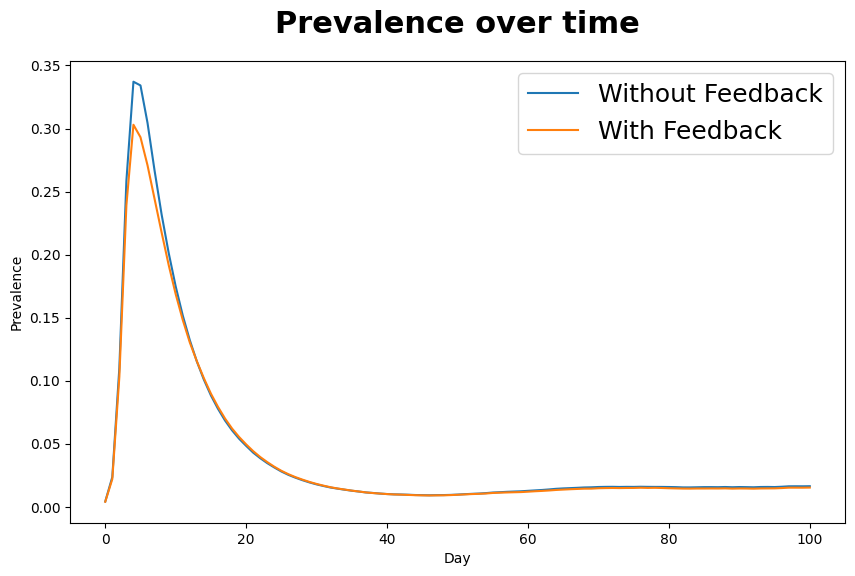

In [15]:
# Plot
plt.figure(figsize=(10, 6))
plt.plot(sim_base.results.timevec, sim_base.results.sirs.prevalence, label='Without Feedback')
plt.plot(sim_ee.results.timevec, sim_ee.results.sirs.prevalence, label='With Feedback')
plt.title('Prevalence over time', fontsize=22, fontweight='bold', pad=20)
plt.ylabel('Prevalence')
plt.xlabel('Day')
plt.legend(loc='upper right', fontsize=18)
plt.savefig(f'{pars_geopops['path']}/figures/prevalence.png')
plt.show()

## Infected workers

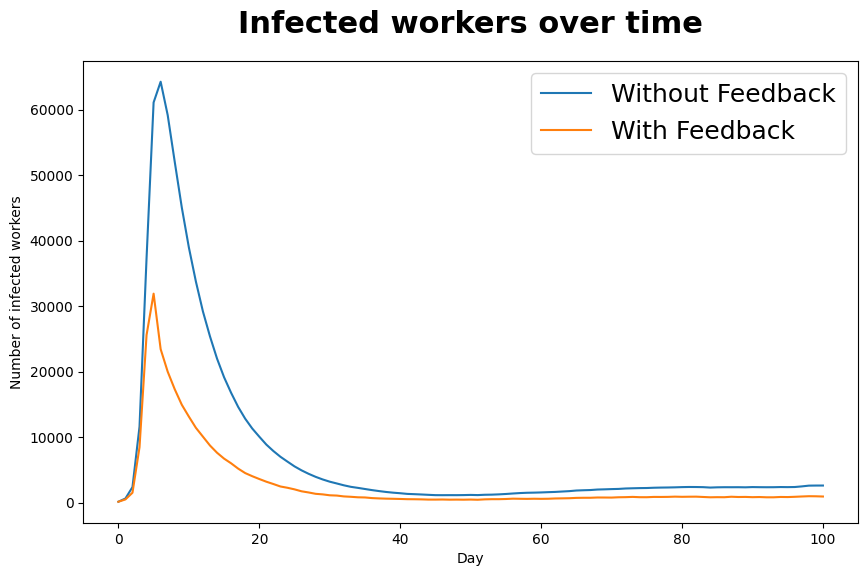

In [16]:
# Plot
plt.figure(figsize=(10, 6))
plt.plot(sim_base.results.timevec, infected_workers_lst, label='Without Feedback')
plt.plot(sim_ee.results.timevec, fb_infected_workers_lst, label='With Feedback')
plt.title('Infected workers over time', fontsize=22, fontweight='bold', pad=20)
plt.ylabel('Number of infected workers')
plt.xlabel('Day')
plt.legend(loc='upper right', fontsize=18)
plt.savefig(f'{pars_geopops['path']}/figures/infected_workers.png')
plt.show()

## Number of people working

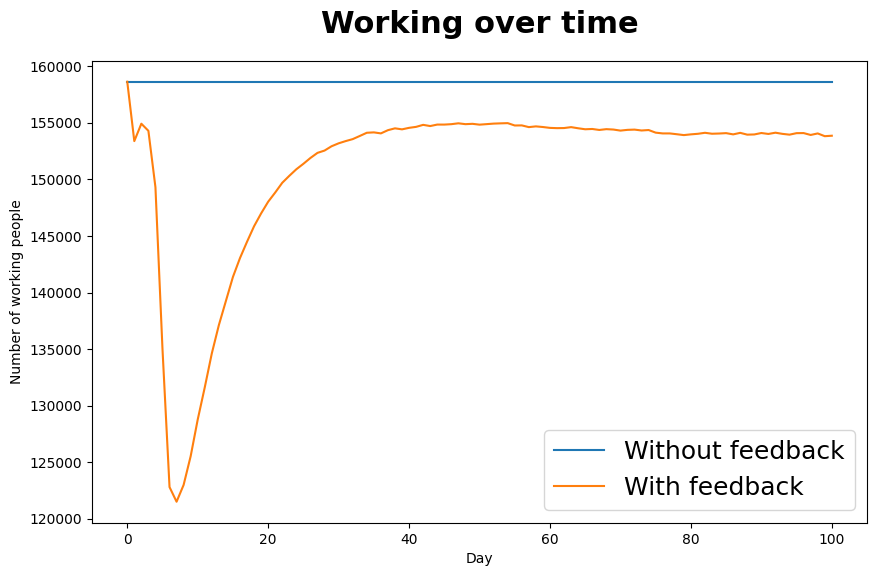

In [17]:
# Plot
plt.figure(figsize=(10, 6))
plt.plot(sim_base.results.timevec, working_lst, label='Without feedback')
plt.plot(sim_ee.results.timevec, fb_working_lst, label='With feedback')
plt.title('Working over time', fontsize=22, fontweight='bold', pad=20)
plt.ylabel('Number of working people')
plt.xlabel('Day')
plt.legend(loc='lower right', fontsize=18)
plt.savefig(f'{pars_geopops['path']}/figures/working.png')
plt.show()



## Active work edges

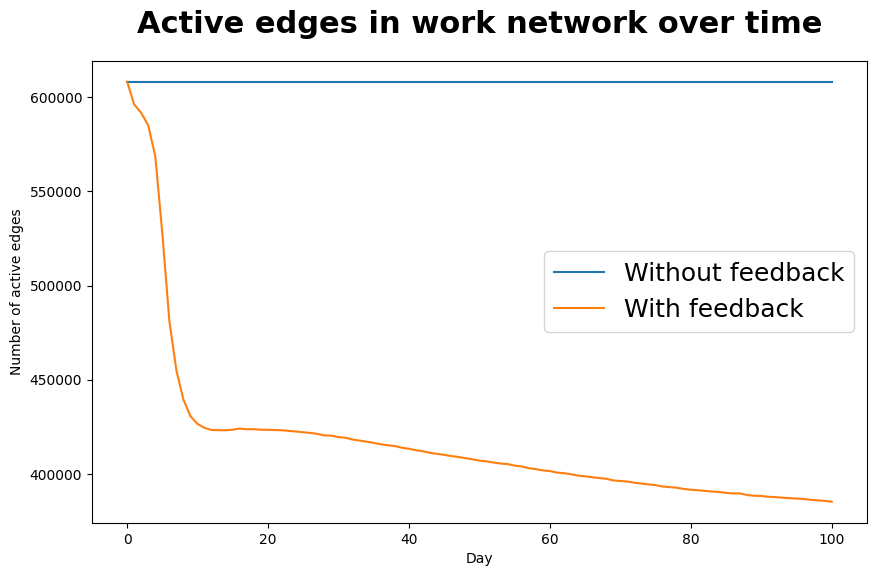

In [18]:
# Plot
plt.figure(figsize=(10, 6))
plt.plot(sim_base.results.timevec, active_edges_lst, label='Without feedback')
plt.plot(sim_ee.results.timevec, fb_active_edges_lst, label='With feedback')
plt.title('Active edges in work network over time', fontsize=22, fontweight='bold', pad=20)
plt.ylabel('Number of active edges')
plt.xlabel('Day')
plt.legend(loc='center right', fontsize=18)
plt.savefig(f'{pars_geopops['path']}/figures/work_edges.png')
plt.show()


## Infections by age group

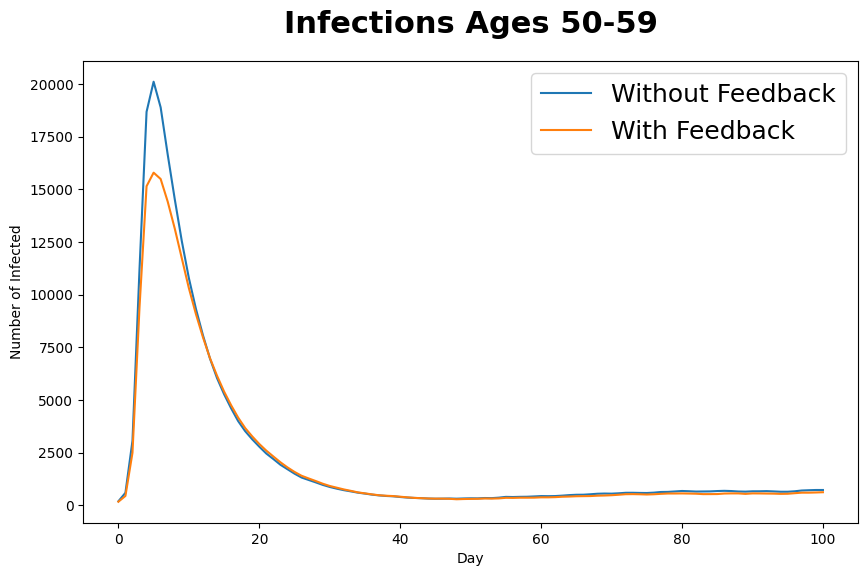

In [19]:
# No feedback dataframe
agegroup = sim_base.analyzers[1].get_subgroup_data().iloc[:-1] 
df_plot = agegroup.set_index('agegroup').T

# With feedback dataframe
agegroup_fb = sim_ee.analyzers[1].get_subgroup_data().iloc[:-1] 
df_plot_fb = agegroup_fb.set_index('agegroup').T

# Plot
plt.figure(figsize=(10, 6))
plt.plot(sim_base.results.timevec, df_plot[5.0], label='Without Feedback')
plt.plot(sim_base.results.timevec, df_plot_fb[5.0], label='With Feedback')
plt.title('Infections Ages 50-59', fontsize=22, fontweight='bold', pad=20)
plt.ylabel('Number of Infected')
plt.xlabel('Day')
plt.legend(loc='upper right', fontsize=18)
plt.savefig(f'{pars_geopops['path']}/figures/ages_50_59.png')
plt.show()

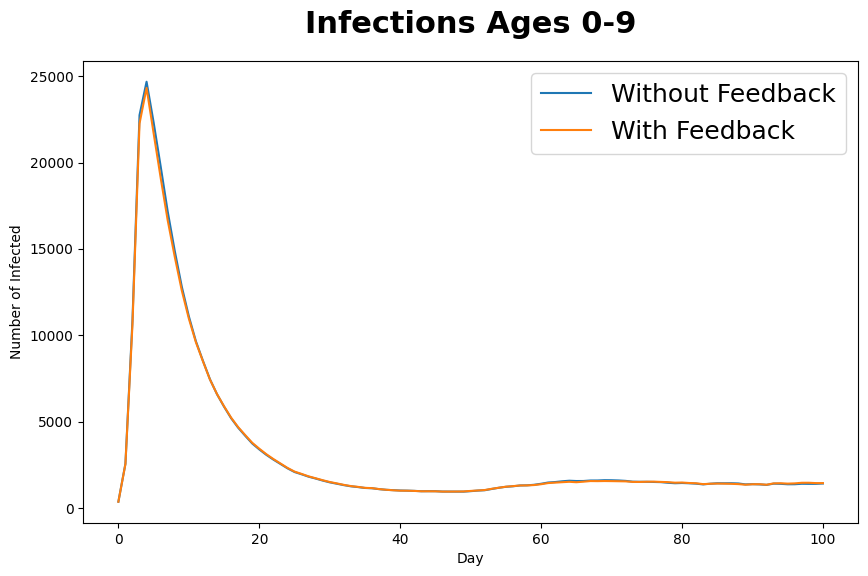

In [20]:
# Plot
plt.figure(figsize=(10, 6))
plt.plot(sim_base.results.timevec, df_plot[0.0], label='Without Feedback')
plt.plot(sim_base.results.timevec, df_plot_fb[0.0], label='With Feedback')
plt.title('Infections Ages 0-9', fontsize=22, fontweight='bold', pad=20)
plt.ylabel('Number of Infected')
plt.xlabel('Day')
plt.legend(loc='upper right', fontsize=18)
plt.savefig(f'{pars_geopops['path']}/figures/ages_0_9.png')
plt.show()


# Infections by CBG with feedback

In [21]:
cbg_df = sim_ee.analyzers[0].get_subgroup_data() # Returns second analyzer (cbg_tracking) as dataframe

ppl_df = sim.people.to_df() # map cbg_id to population per cbg
ppl_df = ppl_df.groupby('cbg_id').size().reset_index()
ppl_df = ppl_df.rename(columns={0: 'pop'})

cbg_df = cbg_df.merge(ppl_df, on='cbg_id', how='left').reset_index()                             
cbg_df['tot_cum_inf'] = cbg_df.drop('cbg_id', axis=1).sum(axis=1) # Sum infections across all days
cbg_df['tot_inf_p100'] = cbg_df['tot_cum_inf'] / cbg_df['pop'] * 100

inf_per_cbg = cbg_df[['cbg_id', 'pop', 'tot_cum_inf', 'tot_inf_p100']] # Keep only cbg_id and infections

cbg_idxs = pd.read_csv(f'{pars_geopops['path']}/pop_export/cbg_idxs.csv') # map cbg_id to cbg_geocode

inf_per_cbg = cbg_idxs.merge(inf_per_cbg, on='cbg_id', how='left')
inf_per_cbg['cbg_geocode'].dtype

cbg_shp = gpd.read_file(f'{pars_geopops['path']}/geo/tl_2019_24_bg.shp')
cbg_shp['cbg_geocode'] = cbg_shp['GEOID'].astype(int)
cbg_shp['cbg_geocode'].dtype
cbg_shp = cbg_shp.merge(inf_per_cbg, on='cbg_geocode', how='left')
cbg_shp.head(100)

,STATEFP,COUNTYFP,TRACTCE,BLKGRPCE,GEOID,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry,cbg_geocode,cbg_id,pop,tot_cum_inf,tot_inf_p100
0,24,021,766800,1,240217668001,Block Group 1,G5030,S,3716906,29841,+39.7144388,-077.3255060,"POLYGON ((-77.35053 39.7199, -77.34956 39.7199...",240217668001,NaN,NaN,NaN,NaN
1,24,510,260202,2,245102602022,Block Group 2,G5030,S,386535,0,+39.3213360,-076.5517123,"POLYGON ((-76.5608 39.32591, -76.56071 39.3261...",245102602022,NaN,NaN,NaN,NaN
2,24,510,130805,1,245101308051,Block Group 1,G5030,S,1632325,6396,+39.3521339,-076.6522287,"POLYGON ((-76.66035 39.35521, -76.66019 39.355...",245101308051,NaN,NaN,NaN,NaN
3,24,025,305100,4,240253051004,Block Group 4,G5030,S,33171360,129620,+39.6378390,-076.3653432,"POLYGON ((-76.41252 39.63971, -76.41252 39.639...",240253051004,NaN,NaN,NaN,NaN
4,24,510,260605,6,245102606056,Block Group 6,G5030,S,8428004,7137768,+39.2571476,-076.5473462,"POLYGON ((-76.57759 39.27161, -76.57269 39.275...",245102606056,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,24,031,702102,1,240317021021,Block Group 1,G5030,S,732600,26311,+39.0234063,-077.0008455,"POLYGON ((-77.01105 39.02471, -77.01098 39.025...",240317021021,NaN,NaN,NaN,NaN
96,24,031,702102,2,240317021022,Block Group 2,G5030,S,487307,0,+39.0225356,-077.0064939,"POLYGON ((-77.01239 39.02061, -77.01217 39.020...",240317021022,NaN,NaN,NaN,NaN
97,24,031,702200,3,240317022003,Block Group 3,G5030,S,371638,0,+39.0110868,-077.0113593,"POLYGON ((-77.01841 39.00872, -77.01823 39.008...",240317022003,NaN,NaN,NaN,NaN
98,24,031,703401,2,240317034012,Block Group 2,G5030,S,343121,0,+39.0615957,-077.0774157,"POLYGON ((-77.0839 39.06184, -77.08304 39.0623...",240317034012,NaN,NaN,NaN,NaN


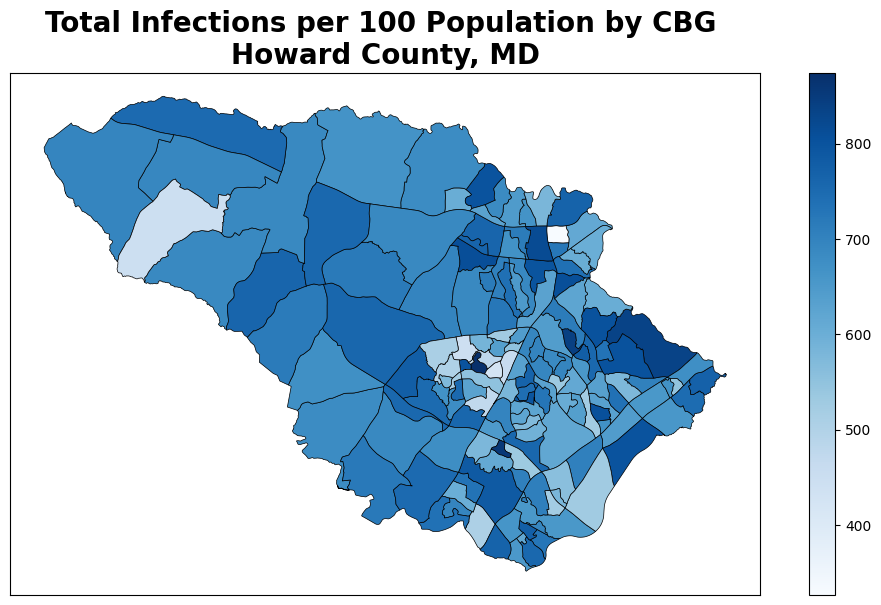

In [22]:
# Create the map
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Plot the map with tot_cum_inf as the color
cbg_shp.plot(column='tot_inf_p100', 
               cmap='Blues',  # Red color scheme (darker = more infections)
               legend=True,
               ax=ax,
               edgecolor='black',
               linewidth=0.5)

# Customize the plot
ax.set_title('Total Infections per 100 Population by CBG \nHoward County, MD', fontsize=20, fontweight='bold')

# Remove axis ticks for cleaner look
ax.set_xticks([])
ax.set_yticks([])

# Add a colorbar with better formatting
cbar = ax.get_figure().get_axes()[1]  # Get the colorbar
cbar.set_label('Total Infections per 100 Population')

plt.tight_layout()
plt.savefig(f'{pars_geopops['path']}/figures/infections_by_cbg.png')
plt.show()

## Population by CBG

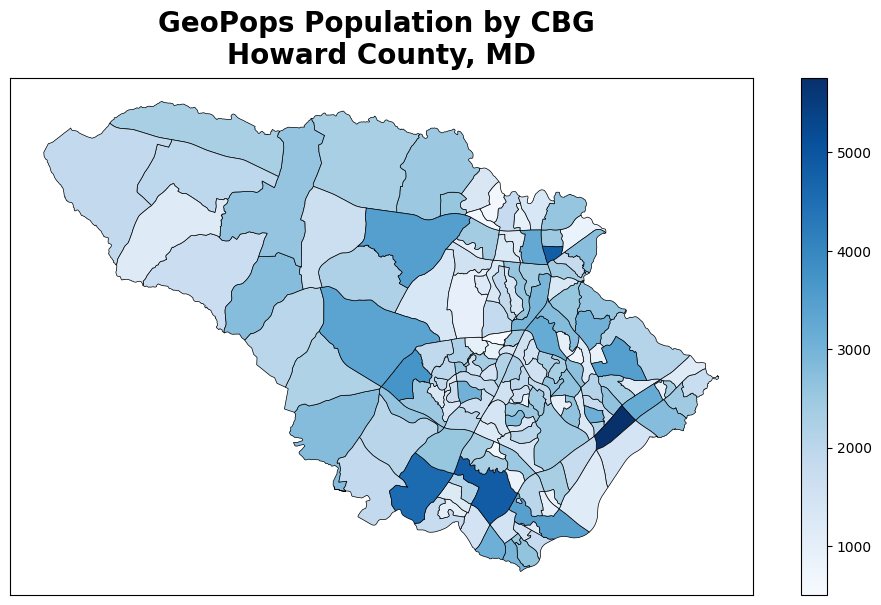

In [23]:
# Create the map
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Plot the map with tot_cum_inf as the color
cbg_shp.plot(column='pop', 
               cmap='Blues',  # Red color scheme (darker = more infections)
               legend=True,
               ax=ax,
               edgecolor='black',
               linewidth=0.5)

# Customize the plot
ax.set_title('GeoPops Population by CBG \nHoward County, MD', fontsize=20, fontweight='bold', pad=10)

# Remove axis ticks for cleaner look
ax.set_xticks([])
ax.set_yticks([])

# Add a colorbar with better formatting
cbar = ax.get_figure().get_axes()[1]  # Get the colorbar

plt.tight_layout()
plt.savefig(f'{pars_geopops['path']}/figures/population_by_cbg.png')
plt.show()

## Maryland counties

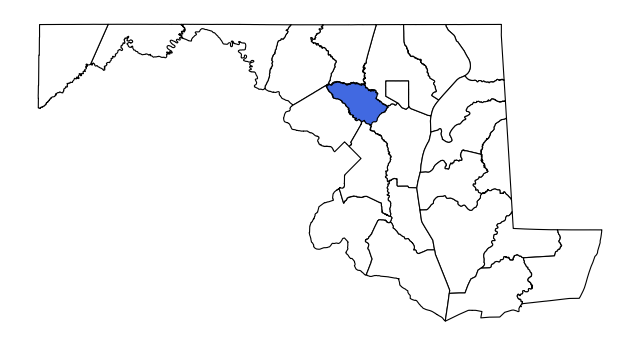

In [24]:
# Build county geometries from CBGs
counties = cbg_shp.dissolve(by='COUNTYFP', as_index=False)

# Howard County (FIPS 027)
howard = cbg_shp[cbg_shp['COUNTYFP'] == '027'].dissolve()
fig, ax = plt.subplots(figsize=(8, 8))
# Draw all counties in white with black outlines
counties.plot(ax=ax, facecolor='white', edgecolor='black', linewidth=0.8)
# Overdraw Howard County in blue
howard.plot(ax=ax, color='royalblue', edgecolor='black', linewidth=0.8)
ax.set_axis_off()
plt.savefig(f'{pars_geopops['path']}/figures/maryland_counties.png',transparent=True)
plt.show()

## QR code

QR code saved to: /Users/Alisa/Library/CloudStorage/OneDrive-JohnsHopkins/Research/GeoPops_all/geopops/tutorials/Epidemics/figures/epidemics_qr_code.png


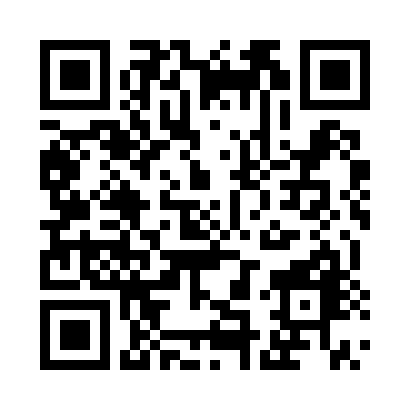

In [29]:
import qrcode
from PIL import Image

# Website URL
url = "https://github.com/ACCIDDA/GeoPops/tree/main/tutorials/Epidemics"

# Create QR code instance
qr = qrcode.QRCode(
    version=1,
    error_correction=qrcode.constants.ERROR_CORRECT_L,
    box_size=10,
    border=4,
)

# Add data to QR code
qr.add_data(url)
qr.make(fit=True)

# Create image from QR code
img = qr.make_image(fill_color="black", back_color="white")

# Save the image
output_path = f'{pars_geopops['path']}/figures/epidemics_qr_code.png'
img.save(output_path)
print(f"QR code saved to: {output_path}")

# Display the image (for Jupyter notebooks)
from IPython.display import display
display(img)